In [ ]:
import sys
sys.path.append('../')
from tqdm import tqdm
import os
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from utilities import load_embedding
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from utilities import print_exams

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)

    return pd.DataFrame(merged_rows)

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def convert_to_pivot_with_serum_names(expand_df, serum_df, preserve_metadata=True):
    """
    将expand_df转换为透视表，列名为serumName
    
    参数:
    expand_df: 原始DataFrame
    serum_df: 包含index_a和serumName映射的DataFrame
    preserve_metadata: 是否保留其他列信息
    
    返回:
    pivot_df: 列名为serumName的透视表
    """
    
    print("=== 转换为带serumName的透视表 ===")
    
    # 创建index_a到serumName的映射
    serum_mapping = dict(zip(serum_df['index_a'], serum_df['serumName']))
    print(f"创建了{len(serum_mapping)}个映射关系")
    
    # 创建透视表
    pivot_df = expand_df.pivot_table(
        index='index_b',
        columns='index_a', 
        values='prediction',
        aggfunc='first',
        fill_value=None
    ).reset_index()
    
    # 重命名列为serumName
    columns_to_rename = {}
    for col in pivot_df.columns:
        if col != 'index_b':  # 保留index_b列
            if col in serum_mapping:
                columns_to_rename[col] = serum_mapping[col]
            else:
                columns_to_rename[col] = f"Unknown_{col}"
    
    pivot_df = pivot_df.rename(columns=columns_to_rename)
    
    # 保留其他列信息（如果需要）
    if preserve_metadata:
        other_cols = [col for col in expand_df.columns 
                      if col not in ['index_a', 'index_b', 'prediction']]
        
        for col in other_cols:
            col_values = expand_df.groupby('index_b')[col].first().reset_index()
            col_values.columns = ['index_b', col]
            pivot_df = pivot_df.merge(col_values, on='index_b', how='left')
    
    print(f"转换完成！形状: {pivot_df.shape}")
    return pivot_df
    
device = torch.device('cuda:3')

## 1 Figure 4A

### 1.1 Data loading

In [2]:
Crick_all = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/all.csv')
Crick_41 = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/Crick_41.csv')

In [86]:
Crick_serum = Crick_all[['seq_id_a', 'seq_id_b', 'seq_a', 'seq_b', 'serumPassCat', 'serumName', 'serumDate', 'serumIslID']].drop_duplicates().copy()
early_vac_serum = Crick_serum[Crick_serum['serumName'] == 'A/DARWIN/9/2021']
early_vac_serum.loc[:, 'seq_id_a'] = early_vac_serum['seq_id_a'].copy() + '_early'
early_vac_serum.loc[:, 'seq_id_b'] = early_vac_serum['seq_id_b'].copy() + '_early'

Vaccine = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/Vaccination.csv')
Vaccine['label'] = Vaccine['HI_Dist']
Vaccine['Type'] = Vaccine['serumType']
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Crick_41.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Vaccine_final = Vaccine.groupby(group_columns).agg(agg_dict).reset_index()

serum = Vaccine_final[['seq_id_a', 'seq_id_b', 'seq_a', 'seq_b', 'serumPassCat', 'serumName']].drop_duplicates().copy()
serum = pd.concat([serum, early_vac_serum])
virus = Vaccine_final[['seq_id_c', 'seq_id_d', 'seq_c', 'seq_d', 'virusPassCat', 'virusName']].drop_duplicates().copy()
Vaccine_artificial = serum.merge(virus, how='cross')
Vaccine_artificial['label'] = 0

Dataloader_Vaccine = DataLoader(fluProfiler_Dataset(Vaccine_artificial), batch_size=10, shuffle=False)

In [12]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)

In [13]:
emb_dict_vac = load_embedding('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_vac')

Loading tensor: 100%|██████████| 246/246 [00:25<00:00,  9.77file/s]


In [14]:
sequence_names = pd.concat([early_vac_serum['seq_id_a'], early_vac_serum['seq_id_b']]).str.replace('_early', '').unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
emb_dict_early_vac = load_embedding('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_Crick', sequence_names)
emb_dict_early_vac = {key+'_early': value for key, value in emb_dict_early_vac.items()}

Loading tensor: 100%|██████████| 3/3 [00:00<00:00, 24.07file/s]


In [15]:
emb_dict_vac = emb_dict_vac | emb_dict_early_vac

In [16]:
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in Dataloader_Vaccine:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_vac[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_vac[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_vac[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_vac[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                        labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

result = print_exams(reference_ls, prediction_ls)

MAE: 1.14083
MSE: 1.96859
pearson correlation: nan
spearman correlation: nan
R2_score: -1.40237


/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/src/Section3_ActiveLearning/../utilities.py:72: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  MAE, MSE, Pearson, Spearman, R2 = mean_absolute_error(O, P), mean_squared_error(O, P), pearsonr(O, P), spearmanr(O, P), r2_score(O, P)


In [172]:
Vaccine_artificial['prediction'] = prediction_ls

### 1.2 Data for plot

In [201]:
'''
将Vaccine_artificial数据聚合成行位病毒，列为血清的表，方便后续处理
'''
# 定义索引A和索引B的列
index_a_cols = ['seq_a', 'seq_b', 'serumPassCat', 'serumName']
index_b_cols = ['seq_c', 'seq_d', 'virusPassCat', 'virusName']

# 需要保留的列
preserve_cols = ['serumName', 'virusName', 'serumPassCat', 'virusPassCat']


# 创建展开后的数据
expanded_data = []

for idx, row in Vaccine_artificial.iterrows():
    # 创建索引A的组合
    index_a = tuple(row[col] for col in index_a_cols)
    
    # 创建索引B的组合  
    index_b = tuple(row[col] for col in index_b_cols)
    
    # 创建新行
    new_row = {
        'index_a': str(index_a),
        'index_b': str(index_b),
        'prediction': row['prediction']
    }
    
    # 添加保留的列
    for col in preserve_cols:
        new_row[col] = row[col]
    
    expanded_data.append(new_row)

# 转换为DataFrame
expanded_df = pd.DataFrame(expanded_data)

print(f"展开后数据形状: {expanded_df.shape}")
print(f"展开后数据列名: {expanded_df.columns.tolist()}")

展开后数据形状: (2816, 7)
展开后数据列名: ['index_a', 'index_b', 'prediction', 'serumName', 'virusName', 'serumPassCat', 'virusPassCat']


In [197]:
expanded_df

In [202]:
expanded_df = expanded_df.drop_duplicates(subset=['index_b', 'serumName', 'serumPassCat'])
serum_df = expanded_df[['index_a', 'serumName', 'serumPassCat', 'virusPassCat']]
pivot_df_with_serum = convert_to_pivot_with_serum_names(expanded_df, serum_df)

=== 转换为带serumName的透视表 ===
创建了14个映射关系
转换完成！形状: (176, 19)


In [187]:
##血清信息
serum_df = expanded_df[['index_a', 'serumName', 'serumPassCat']]
serum_df = serum_df.drop_duplicates(subset=['serumName', 'serumPassCat'])
# serum_df['serumName'] = serum_df['serumName'] + ' ' + serum_df['serumPassCat'].str.replace('<', '').str.replace('>', '')

## 转换为pivot表
pivot_df_with_serum = convert_to_pivot_with_serum_names(expanded_df, serum_df)

=== 转换为带serumName的透视表 ===
创建了14个映射关系
转换完成！形状: (176, 20)


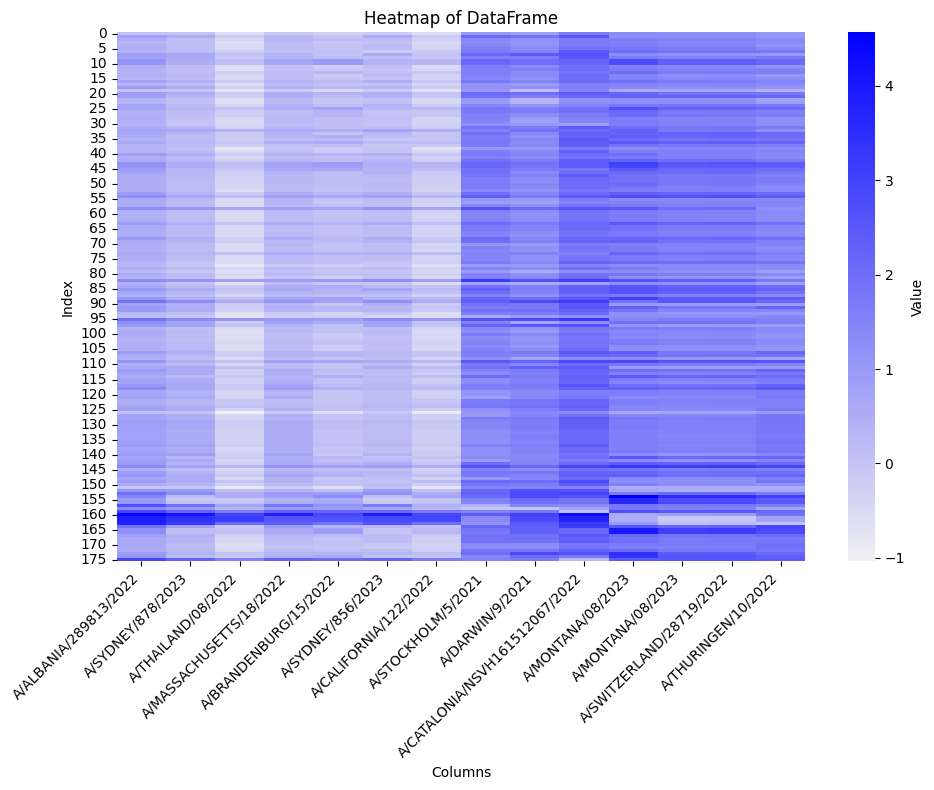

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pivot_df_with_serum.iloc[:,1:15]

plt.figure(figsize=(10,8))
cmap = sns.light_palette("blue", as_cmap=True)
ax = sns.heatmap(df, cmap=cmap, annot=False, fmt=".2f", cbar_kws={'label': 'Value'})

# 旋转 x 轴标签 45 度，并右对齐
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.xlabel("Columns")
plt.ylabel("Index")
plt.title("Heatmap of DataFrame")
plt.tight_layout()
plt.show()


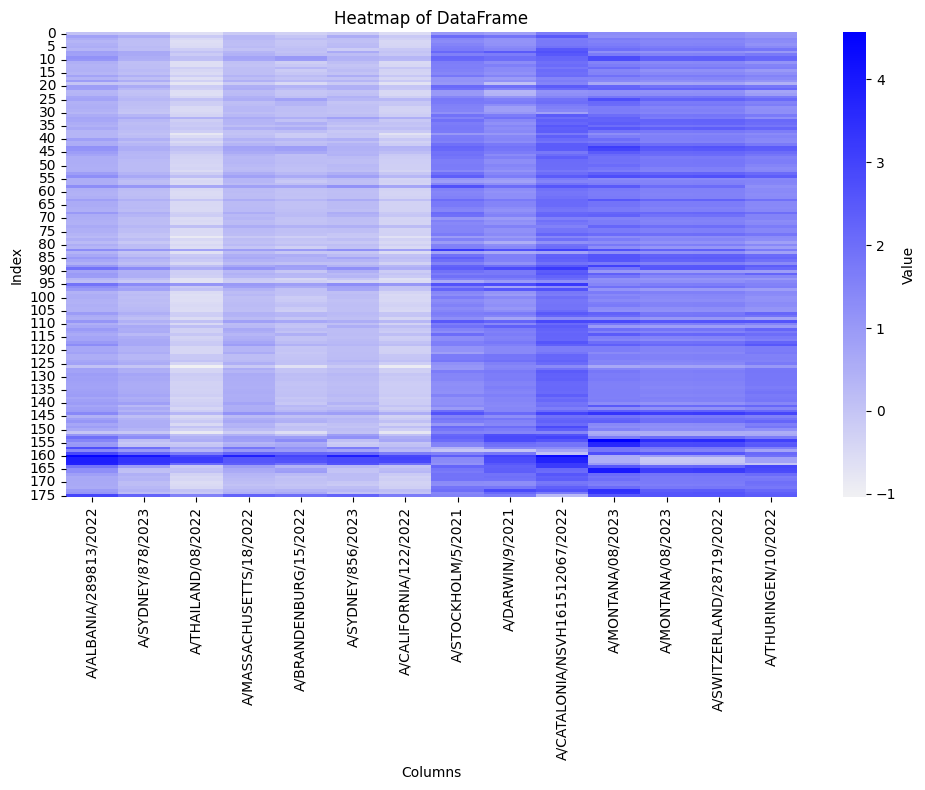

In [205]:
df = pivot_df_with_serum.iloc[:,1:15]
# 假设你的 DataFrame 是 df
plt.figure(figsize=(10,8))
cmap = sns.light_palette("blue", as_cmap=True)
sns.heatmap(df, cmap=cmap, annot=False, fmt=".2f", cbar_kws={'label': 'Value'})
plt.xlabel("Columns")
plt.ylabel("Index")
# plt.xticks(rotation=20)
plt.title("Heatmap of DataFrame")
plt.tight_layout()
plt.show()


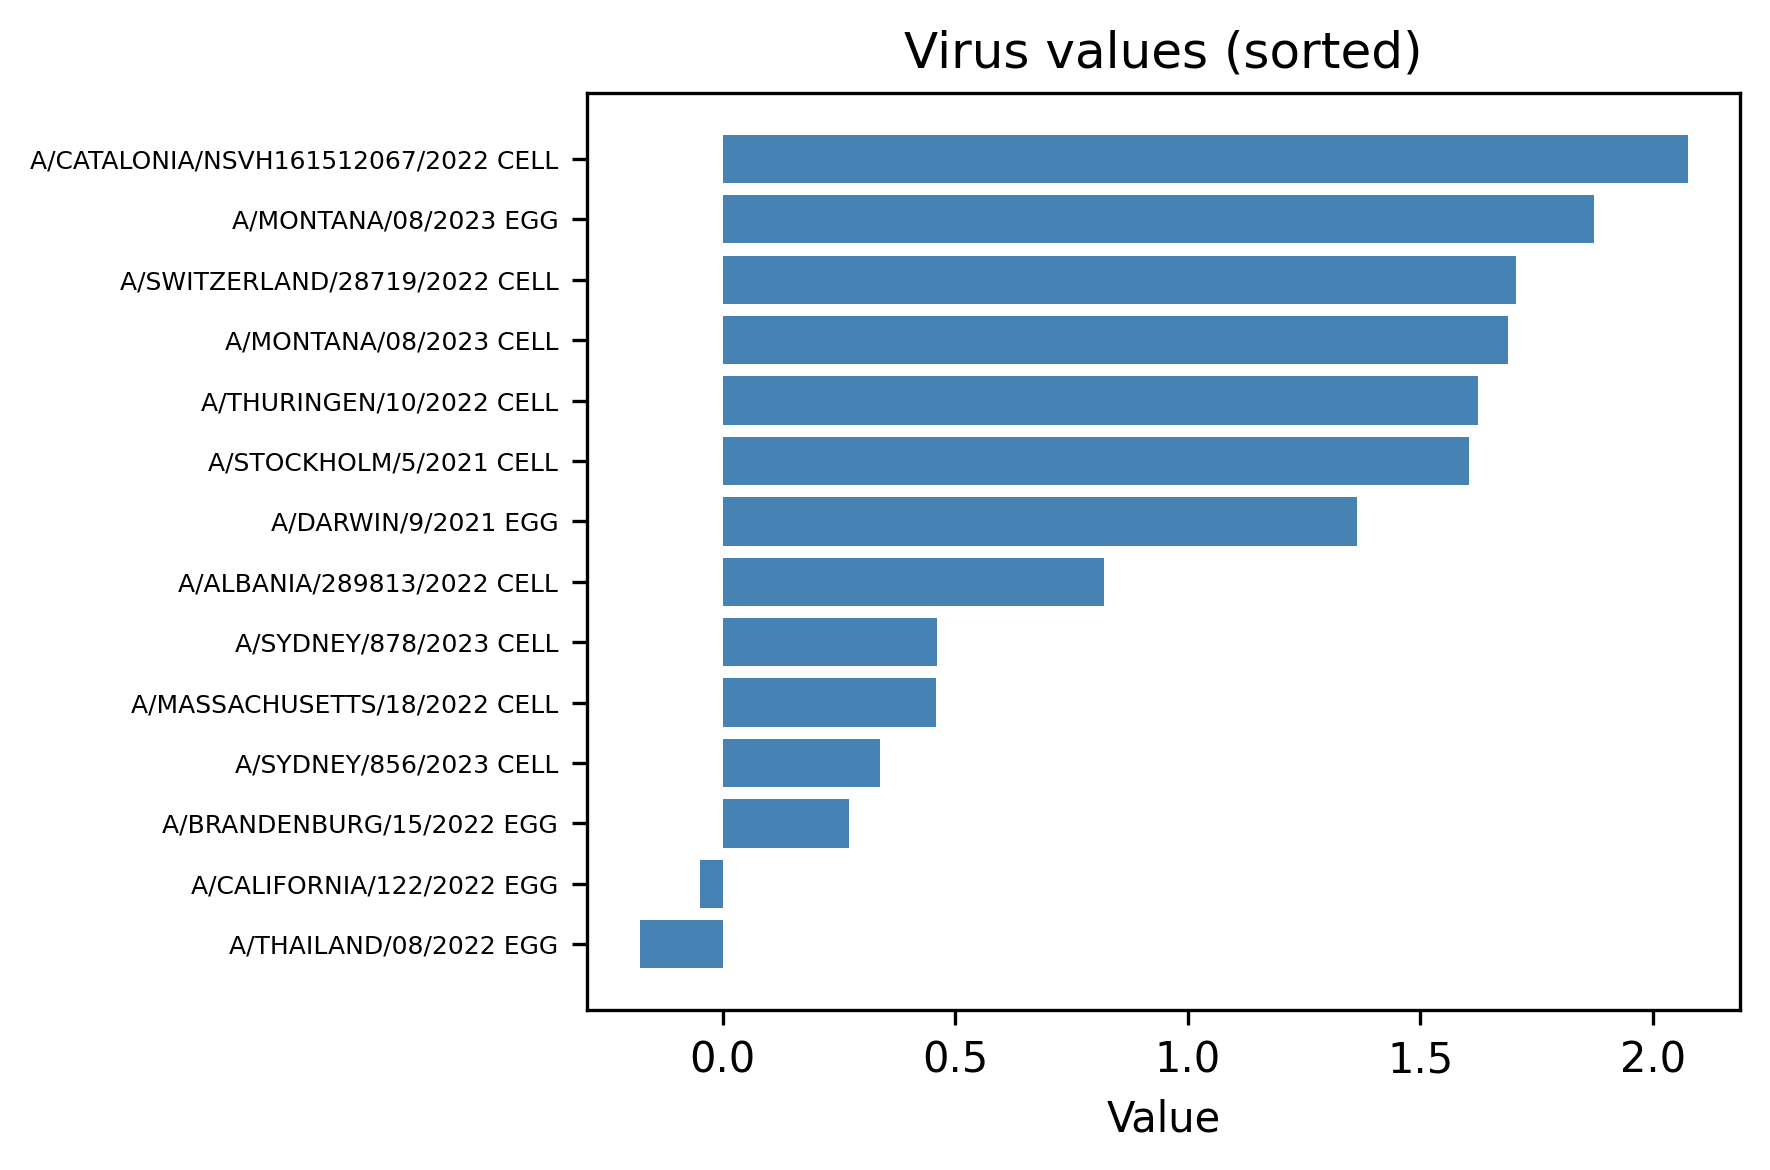

In [90]:
import matplotlib.pyplot as plt

my_Series = pivot_df_with_serum.iloc[:,1:16].mean(skipna=True)
my_Series = my_Series[~my_Series.index.duplicated(keep='first')]
# 按 value 排序
df = my_Series.sort_values(ascending=False)
# 画横向条形图
plt.figure(figsize=(6, 4), dpi=300)
plt.barh(df.index, df.values, color="steelblue")
plt.gca().invert_yaxis()  # 让最大值在最上面
plt.xlabel("Value")
plt.yticks(size=6)
plt.title("Virus values (sorted)")
plt.tight_layout()
plt.show()

In [78]:
my_Series.sort_values(ascending=True)

A/THAILAND/08/2022 EGG                -0.178395
A/CALIFORNIA/122/2022 EGG             -0.049574
A/BRANDENBURG/15/2022 EGG              0.270737
A/SYDNEY/856/2023 CELL                 0.338377
A/MASSACHUSETTS/18/2022 CELL           0.457798
A/SYDNEY/878/2023 CELL                 0.461568
A/ALBANIA/289813/2022 CELL             0.819651
A/DARWIN/9/2021 EGG                    1.365015
A/DARWIN/9/2021 EGG                    1.546122
A/STOCKHOLM/5/2021 CELL                1.605780
A/THURINGEN/10/2022 CELL               1.624942
A/MONTANA/08/2023 CELL                 1.688210
A/SWITZERLAND/28719/2022 CELL          1.706376
A/MONTANA/08/2023 EGG                  1.873722
A/CATALONIA/NSVH161512067/2022 CELL    2.075336
dtype: float64

In [104]:
my_Series

A/ALBANIA/289813/2022 CELL             0.819651
A/SYDNEY/878/2023 CELL                 0.461568
A/THAILAND/08/2022 EGG                -0.178395
A/MASSACHUSETTS/18/2022 CELL           0.457798
A/BRANDENBURG/15/2022 EGG              0.270737
A/SYDNEY/856/2023 CELL                 0.338377
A/CALIFORNIA/122/2022 EGG             -0.049574
A/STOCKHOLM/5/2021 CELL                1.605780
A/DARWIN/9/2021 EGG                    1.365015
A/CATALONIA/NSVH161512067/2022 CELL    2.075336
A/MONTANA/08/2023 EGG                  1.873722
A/MONTANA/08/2023 CELL                 1.688210
A/SWITZERLAND/28719/2022 CELL          1.706376
A/THURINGEN/10/2022 CELL               1.624942
dtype: float64

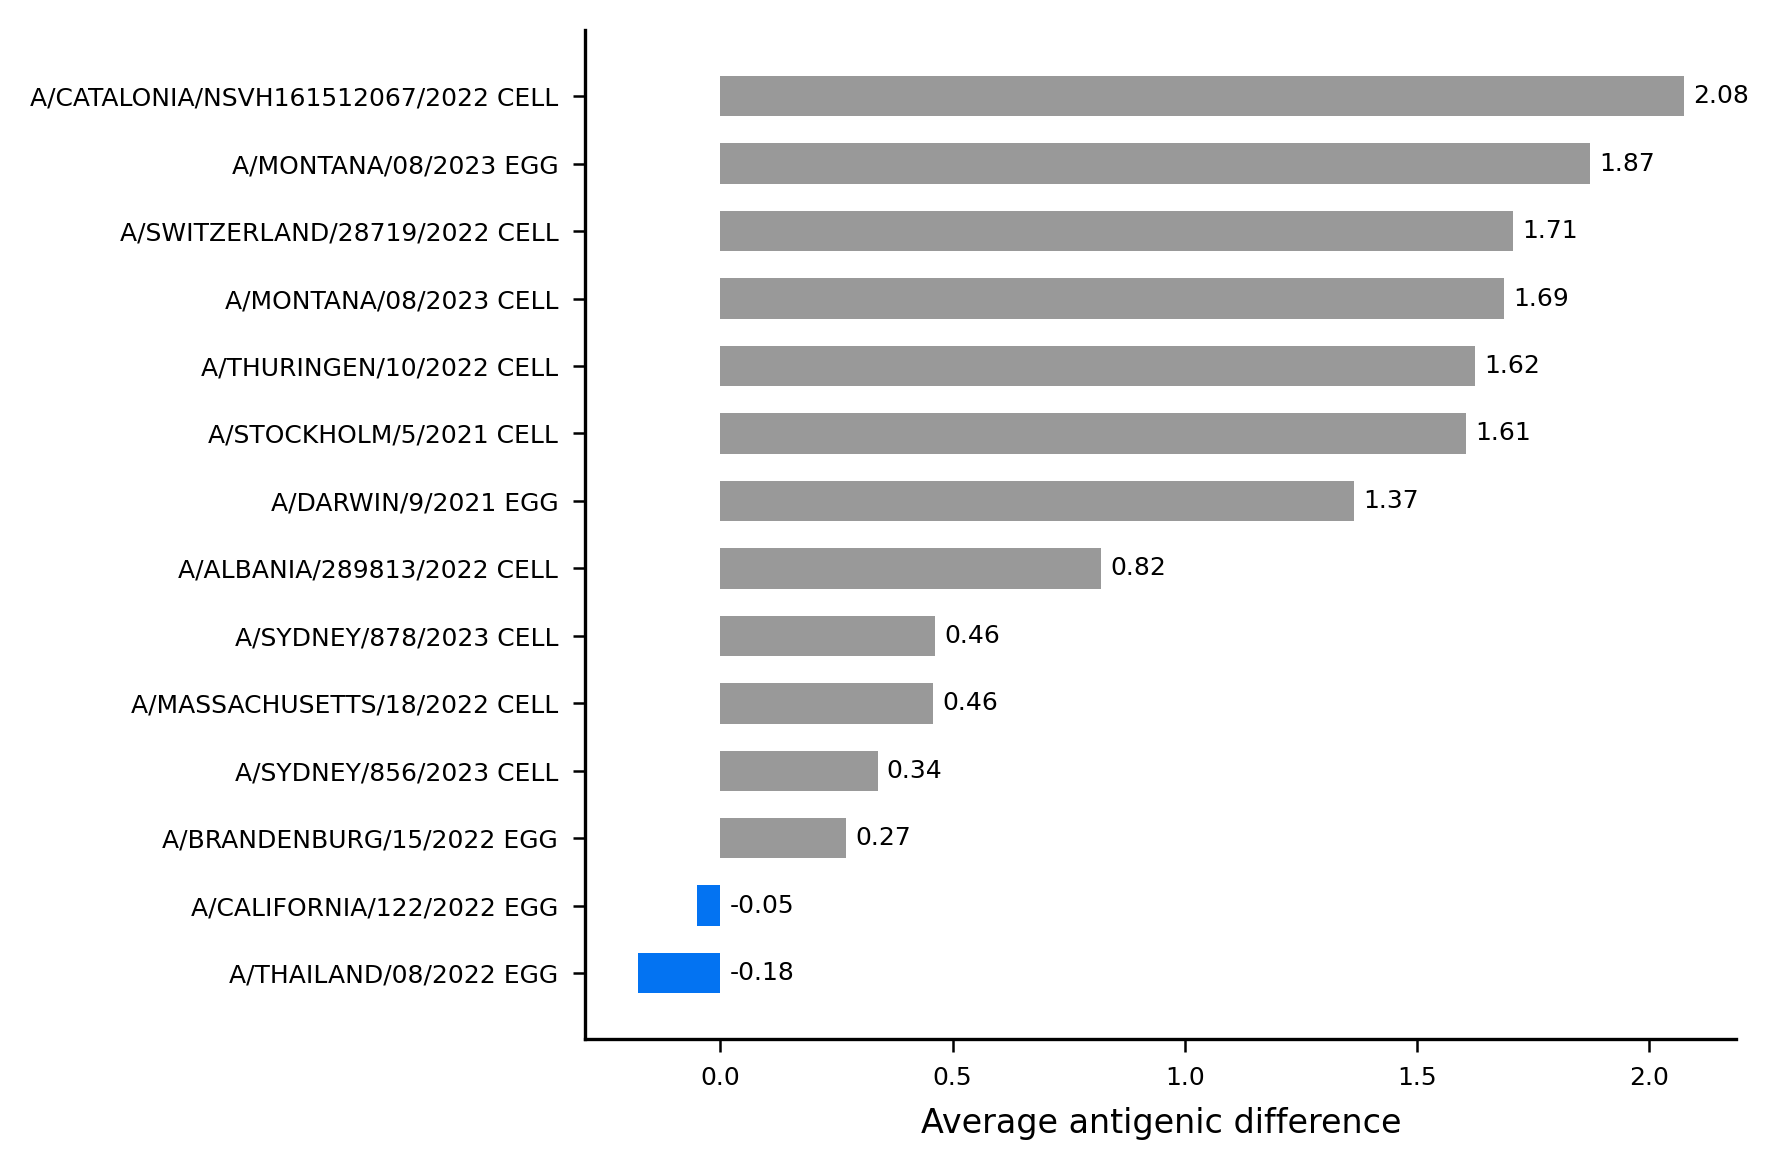

In [105]:
import matplotlib.pyplot as plt

# 计算平均值
my_Series = pivot_df_with_serum.iloc[:,1:16].mean(skipna=True)
my_Series = my_Series[~my_Series.index.duplicated(keep='first')]

# 按升序排序（越小越好 → 上面）
# df = my_Series.sort_values(ascending=True)

# 高亮前3个最小值
base_color = (0.6, 0.6, 0.6)  # 灰色
hl_color   = (0.01, 0.45, 0.95)  # 蓝色高亮
colors = [hl_color if i < 2 else base_color for i in range(len(df))]

# 画图
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
bars = ax.barh(df.index, df.values, color=colors, height=0.6)

# 样式优化（Science/Nature 风格）
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", length=3, width=0.6)
ax.set_xlabel("Average antigenic difference", fontsize=8)

# 在条形右端或0轴右侧标注数值
for bar, v in zip(bars, df.values):
    if v >= 0:
        x = bar.get_width() + 0.02
        ha = "left"
    else:
        x = 0.02  # 紧挨着 0 刻度线右侧
        ha = "left"
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f"{v:.2f}", va="center", ha=ha, fontsize=6)

plt.xticks(size=6)
plt.yticks(size=6)
plt.tight_layout()
plt.show()
